To do some basic stats and models on the pous data; correlations, etc

In [1]:
import pandas as pd

path = r"C:\Users\teaching\Downloads\outage-recovery-forecasting\data_transients"

event_master = pd.read_parquet(f"{path}\\florida_event_master.parquet")
model_df = pd.read_parquet(f"{path}\\florida_model_df.parquet")
coverage_df = pd.read_parquet(f"{path}\\florida_coverage.parquet")

event_master.shape, model_df.shape, coverage_df.shape

((99, 5), (17510, 22), (99, 9))

In [15]:
model_df.head()


,event_id,storm,geoid,county,datetime,event_start,duration_hours,gust_mps,wind_speed_mps,precip_mm,...,CountyFIPS,outageFraction,customersTracked,persistence_1h,error,abs_error,sq_error,persistence_24h,persistence_48h,persistence_72h
0,12001_2017-09-11 03:00:00,2017242N16333,12001,Alachua,2017-09-10 15:00:00,2017-09-11 03:00:00,134,9.545648,6.145859,2.925622,...,12001,0.046551,97979.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,12001_2017-09-11 03:00:00,2017242N16333,12001,Alachua,2017-09-10 16:00:00,2017-09-11 03:00:00,134,10.602325,7.331592,3.961323,...,12001,0.043928,97979.0,0.046551,-0.002623,0.002623,0.000007,NaN,NaN,NaN
2,12001_2017-09-11 03:00:00,2017242N16333,12001,Alachua,2017-09-10 17:00:00,2017-09-11 03:00:00,134,12.677439,7.569997,3.951933,...,12001,0.011002,97979.0,0.043928,-0.032925,0.032925,0.001084,NaN,NaN,NaN
3,12001_2017-09-11 03:00:00,2017242N16333,12001,Alachua,2017-09-10 18:00:00,2017-09-11 03:00:00,134,13.805998,7.402843,3.323243,...,12001,0.003011,97979.0,0.011002,-0.007992,0.007992,0.000064,NaN,NaN,NaN
4,12001_2017-09-11 03:00:00,2017242N16333,12001,Alachua,2017-09-10 19:00:00,2017-09-11 03:00:00,134,18.680332,8.316379,3.520969,...,12001,0.010880,97979.0,0.003011,0.007869,0.007869,0.000062,NaN,NaN,NaN


In [2]:
event_master.head()
event_master[['event_id','storm','CountyFIPS']].nunique()
event_master['duration_hours'].describe()

count     99.000000
mean     152.868687
std      110.021857
min       25.000000
25%       61.000000
50%      147.000000
75%      190.500000
max      553.000000
Name: duration_hours, dtype: float64

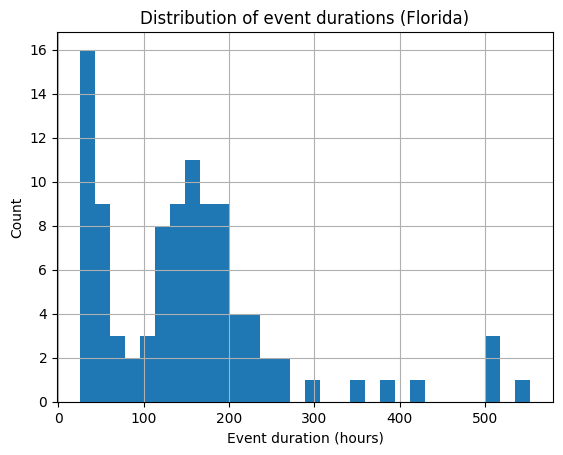

In [9]:
import matplotlib.pyplot as plt

plt.figure()
event_master['duration_hours'].hist(bins=30)
plt.xlabel("Event duration (hours)")
plt.ylabel("Count")
plt.title("Distribution of event durations (Florida)")
plt.show()

In [10]:
df = model_df.copy()

# optional: filter quality
df = df[df['customersTracked'] >= 0.3]

window_stats = (
    df.groupby(['event_id', 'CountyFIPS'])
    .agg(
        peak_outage=('outageFraction', 'max'),
        max_gust=('gust_mps', 'max'),
    )
    .reset_index()
)

# merge duration
window_stats = window_stats.merge(
    event_master[['event_id', 'CountyFIPS', 'duration_hours']],
    on=['event_id', 'CountyFIPS'],
    how='left'
)

window_stats.head()

,event_id,CountyFIPS,peak_outage,max_gust,duration_hours
0,12001_2017-09-11 03:00:00,12001,0.563432,33.576319,134
1,12003_2017-09-11 07:00:00,12003,0.994966,35.975707,162
2,12005_2018-10-10 17:00:00,12005,0.880851,27.984700,504
3,12007_2017-09-11 05:00:00,12007,0.969112,34.513300,165
4,12009_2022-09-29 07:00:00,12009,0.280680,24.754235,62


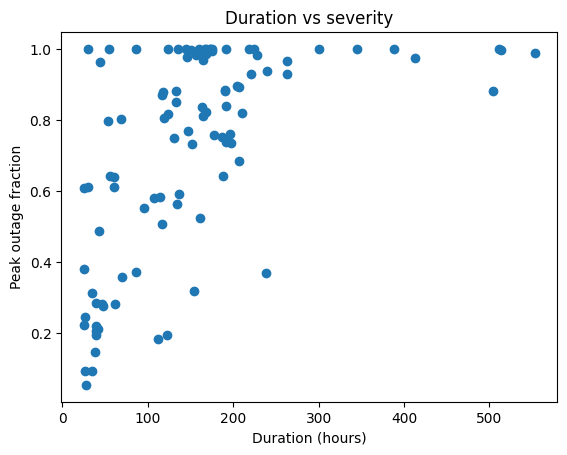

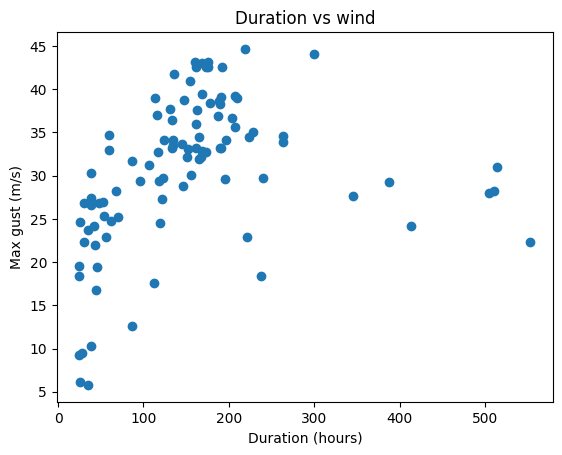

In [12]:
plt.figure()
plt.scatter(window_stats['duration_hours'], window_stats['peak_outage'])
plt.xlabel("Duration (hours)")
plt.ylabel("Peak outage fraction")
plt.title("Duration vs severity")
plt.show()

plt.figure()
plt.scatter(window_stats['duration_hours'], window_stats['max_gust'])
plt.xlabel("Duration (hours)")
plt.ylabel("Max gust (m/s)")
plt.title("Duration vs wind")
plt.show()

In [13]:
window_stats[['peak_outage','max_gust','duration_hours']].corr(method='pearson')

,peak_outage,max_gust,duration_hours
peak_outage,1.000000,0.514274,0.560544
max_gust,0.514274,1.000000,0.311565
duration_hours,0.560544,0.311565,1.000000


In [14]:
window_stats[['peak_outage','max_gust','duration_hours']].corr(method='spearman')

,peak_outage,max_gust,duration_hours
peak_outage,1.000000,0.384675,0.600361
max_gust,0.384675,1.000000,0.522210
duration_hours,0.600361,0.522210,1.000000


Now let's try using also the customersTracked

In [16]:
window_stats['mean_gust'] = (
    df.groupby(['event_id','CountyFIPS'])['gust_mps'].mean().values
)

In [17]:
window_stats[['duration_hours','peak_outage','max_gust','mean_gust']].corr()

,duration_hours,peak_outage,max_gust,mean_gust
duration_hours,1.000000,0.560544,0.311565,-0.495872
peak_outage,0.560544,1.000000,0.514274,-0.304608
max_gust,0.311565,0.514274,1.000000,0.007396
mean_gust,-0.495872,-0.304608,0.007396,1.000000


^weird neg correl?

construct absolute outage proxy:

In [19]:
df = model_df.copy()
df = df[df['customersTracked'] >= 0.3]

# define window
group_cols = ['event_id', 'CountyFIPS']

# stable customer base per window
base_customers = (
    df.groupby(group_cols)['customersTracked']
    .max()
    .rename('base_customers')
    .reset_index()
)

df = df.merge(base_customers, on=group_cols, how='left')

# absolute outage proxy
df['customers_out'] = df['outageFraction'] * df['base_customers']

In [20]:
window_stats = (
    df.groupby(group_cols)
    .agg(
        peak_outage=('outageFraction', 'max'),
        peak_customers_out=('customers_out', 'max'),
        max_gust=('gust_mps', 'max'),
    )
    .reset_index()
)

window_stats = window_stats.merge(
    event_master[['event_id','CountyFIPS','duration_hours']],
    on=['event_id','CountyFIPS'],
    how='left'
)

In [21]:
window_stats[['duration_hours','peak_outage','peak_customers_out']].corr()

,duration_hours,peak_outage,peak_customers_out
duration_hours,1.000000,0.560544,0.12586
peak_outage,0.560544,1.000000,0.15177
peak_customers_out,0.125860,0.151770,1.00000


^?

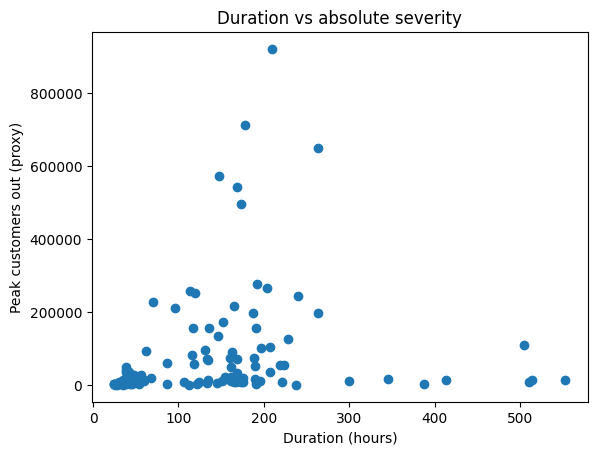

In [22]:
plt.figure()
plt.scatter(window_stats['duration_hours'], window_stats['peak_customers_out'])
plt.xlabel("Duration (hours)")
plt.ylabel("Peak customers out (proxy)")
plt.title("Duration vs absolute severity")
plt.show()

Metrics: t90 and t50 (halflife)

In [23]:
import numpy as np

df = model_df.copy()
df = df[df['customersTracked'] >= 0.3]

group_cols = ['event_id', 'CountyFIPS']

def compute_recovery_metrics(group):
    group = group.sort_values('datetime').copy()

    # find peak
    peak_idx = group['outageFraction'].idxmax()
    peak_time = group.loc[peak_idx, 'datetime']
    peak_val = group.loc[peak_idx, 'outageFraction']

    # subset after peak
    post = group[group['datetime'] >= peak_time].copy()

    # thresholds
    thr_50 = 0.5 * peak_val
    thr_10 = 0.1 * peak_val

    def time_to_threshold(threshold):
        crossed = post[post['outageFraction'] <= threshold]
        if crossed.empty:
            return np.nan
        return (crossed.iloc[0]['datetime'] - peak_time).total_seconds() / 3600

    t50 = time_to_threshold(thr_50)
    t90 = time_to_threshold(thr_10)

    return pd.Series({
        'peak_outage': peak_val,
        't50': t50,
        't90': t90
    })

recovery_df = (
    df.groupby(group_cols)
    .apply(compute_recovery_metrics)
    .reset_index()
)

# merge duration
recovery_df = recovery_df.merge(
    event_master[['event_id','CountyFIPS','duration_hours']],
    on=['event_id','CountyFIPS'],
    how='left'
)

recovery_df.head()

,event_id,CountyFIPS,peak_outage,t50,t90,duration_hours
0,12001_2017-09-11 03:00:00,12001,0.563432,23.0,50.0,134
1,12003_2017-09-11 07:00:00,12003,0.994966,37.0,121.0,162
2,12005_2018-10-10 17:00:00,12005,0.880851,198.0,305.0,504
3,12007_2017-09-11 05:00:00,12007,0.969112,48.0,142.0,165
4,12009_2022-09-29 07:00:00,12009,0.280680,22.0,49.0,62


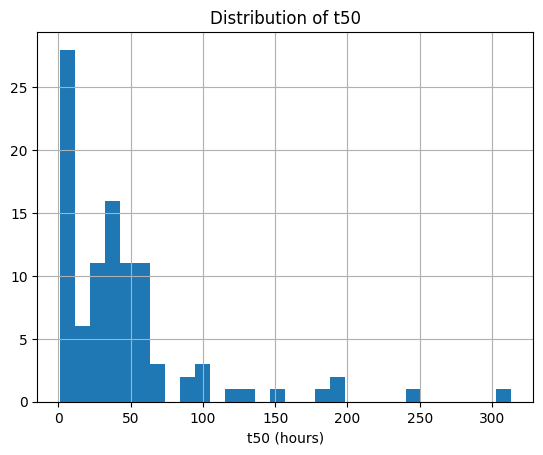

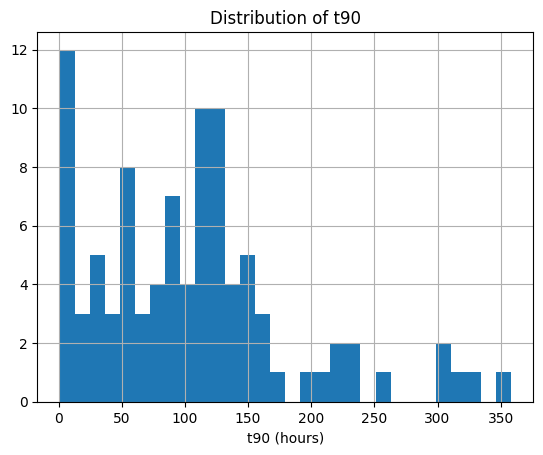

In [32]:
# distributions:
import matplotlib.pyplot as plt

plt.figure()
recovery_df['t50'].hist(bins=30)
plt.xlabel("t50 (hours)")
plt.title("Distribution of t50")
plt.show()

plt.figure()
recovery_df['t90'].hist(bins=30)
plt.xlabel("t90 (hours)")
plt.title("Distribution of t90")
plt.show()

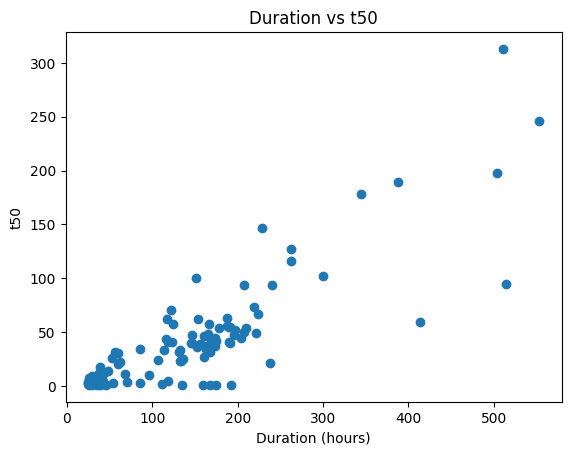

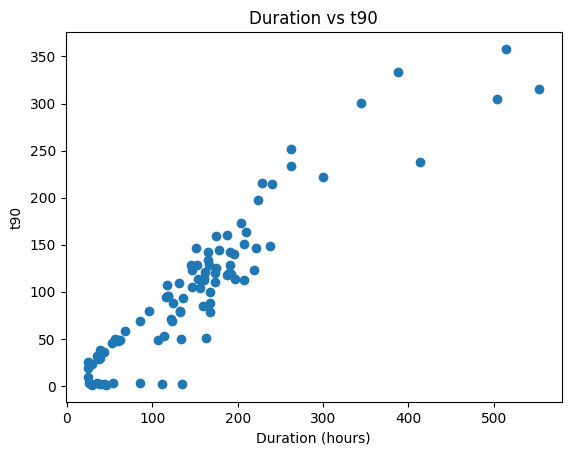

In [33]:
plt.figure()
plt.scatter(recovery_df['duration_hours'], recovery_df['t50'])
plt.xlabel("Duration (hours)")
plt.ylabel("t50")
plt.title("Duration vs t50")
plt.show()

plt.figure()
plt.scatter(recovery_df['duration_hours'], recovery_df['t90'])
plt.xlabel("Duration (hours)")
plt.ylabel("t90")
plt.title("Duration vs t90")
plt.show()

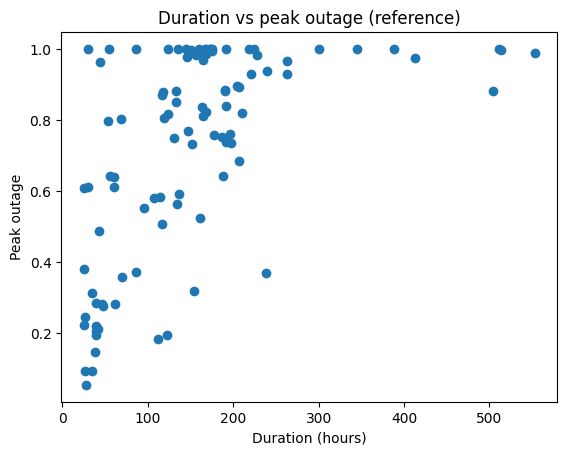

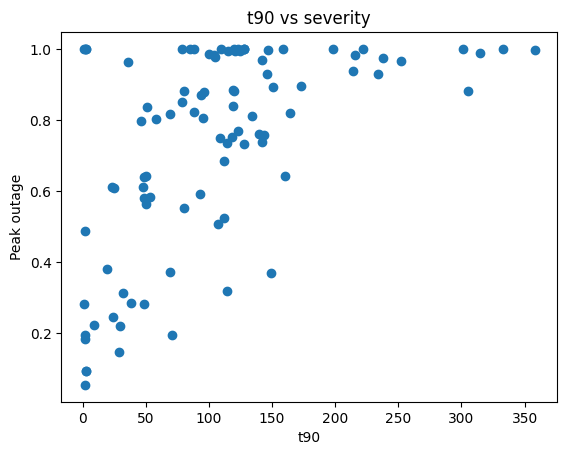

In [ ]:
plt.figure()
plt.scatter(recovery_df['duration_hours'], recovery_df['peak_outage'])
plt.xlabel("Duration (hours)")
plt.ylabel("Peak outage")
plt.title("Duration vs peak outage (reference)")
plt.show()

plt.figure()
plt.scatter(recovery_df['t90'], recovery_df['peak_outage'])
plt.xlabel("t90")
plt.ylabel("Peak outage")
plt.title("t90 vs severity")
plt.show()

Shape;
consider tail length as t90-t50

In [35]:
recovery_df['tail'] = recovery_df['t90'] - recovery_df['t50']

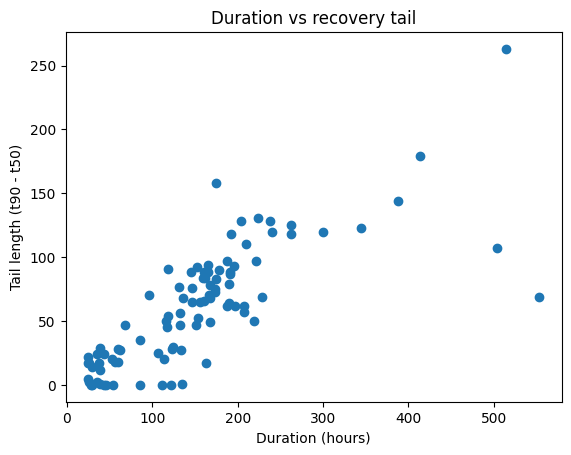

In [36]:
plt.figure()
plt.scatter(recovery_df['duration_hours'], recovery_df['tail'])
plt.xlabel("Duration (hours)")
plt.ylabel("Tail length (t90 - t50)")
plt.title("Duration vs recovery tail")
plt.show()

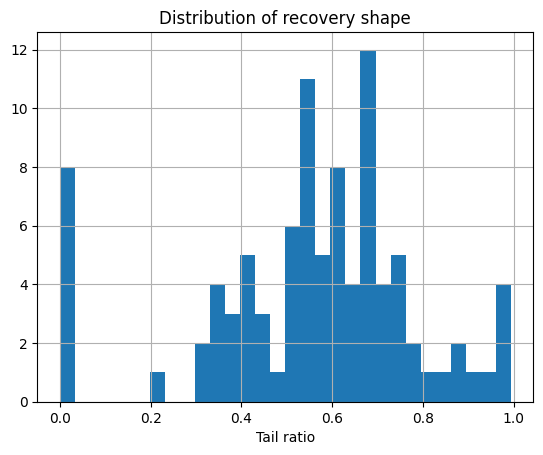

In [37]:
recovery_df['tail_ratio'] = recovery_df['tail'] / recovery_df['t90']

plt.figure()
recovery_df['tail_ratio'].hist(bins=30)
plt.xlabel("Tail ratio")
plt.title("Distribution of recovery shape")
plt.show()